
# PACE OCI downloader

can do either **L2** (`PACE_OCI_L2_TRGAS`) swath downloads or **L3** (`PACE_OCI_L3M_TRGAS`) gridded daily downloads

mounts to shared drive folder, can:
- preview individual days
- calc pixel resolution
- download date range + clip (saves only clipped files)

works as long as input bbox is (south, west, north, east)
- the shared Drive destination is `IDS.S21/data/L2_oci/`
- L2 files expose 2D `latitude` / `longitude` coordinates
- L3 files expose 1D `lat` / `lon` grids


In [1]:

!pip -q install earthaccess "xarray[complete]" rioxarray h5netcdf netCDF4


CLICOLOR=1
CLICOLOR_FORCE=1
COMMAND_MODE=unix2003
CONDA_DEFAULT_ENV=pace-test
CONDA_EXE=/Users/kaijz/conda/bin/conda
CONDA_PREFIX=/Users/kaijz/conda/envs/pace-test
CONDA_PROMPT_MODIFIER='(pace-test) '
CONDA_PYTHON_EXE=/Users/kaijz/conda/bin/python
CONDA_ROOT=/Users/kaijz/conda
CONDA_SHLVL=1
CPL_ZIP_ENCODING=UTF-8
ELECTRON_RUN_AS_NODE=1
ESMFMKFILE=/Users/kaijz/conda/envs/pace-test/lib/esmf.mk
FORCE_COLOR=1
GDAL_DATA=/Users/kaijz/conda/envs/pace-test/share/gdal
GDAL_DRIVER_PATH=/Users/kaijz/conda/envs/pace-test/lib/gdalplugins
GIT_PAGER=cat
HOME=/Users/kaijz
HOMEBREW_CELLAR=/opt/homebrew/Cellar
HOMEBREW_PREFIX=/opt/homebrew
HOMEBREW_REPOSITORY=/opt/homebrew
INFOPATH=/opt/homebrew/share/info:
LC_CTYPE=C.UTF-8
LOGNAME=kaijz
MACH_PORT_RENDEZVOUS_PEER_VALDATION=0
MAMBA_EXE=/Users/kaijz/conda/bin/mamba
MAMBA_ROOT_PREFIX=/Users/kaijz/conda
MPLBACKEND=module://matplotlib_inline.backend_inline
MallocNanoZone=0
OLDPWD=/Users/kaijz/Desktop/IDS-project
PAGER=cat
PATH=/Users/kaijz/conda/envs/pace-te

In [2]:

from pathlib import Path
from datetime import datetime, timedelta
import re
import shutil
import warnings

import earthaccess
import numpy as np
from xarray.backends.api import open_datatree
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt


warnings.filterwarnings("ignore", category=RuntimeWarning)


In [3]:

# (only works for owner of IDS.S21 folder right now), mounts Google Drive + defines output root
# Shared drives are typically visible under /content/drive/Shareddrives after mounting in Colab.


OUTPUT_ROOT = Path('./L2_oci')

TEMP_ROOT = OUTPUT_ROOT / '_temp'
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
TEMP_ROOT.mkdir(parents=True, exist_ok=True)

print('OUTPUT_ROOT =', OUTPUT_ROOT)
print('TEMP_ROOT   =', TEMP_ROOT)


OUTPUT_ROOT = L2_oci
TEMP_ROOT   = L2_oci/_temp


In [ ]:

# Earthdata login
auth = earthaccess.login(persist=True)

In [5]:

PRODUCTS = {
    'L2': {
        'short_name': 'PACE_OCI_L2_TRGAS',
        'granule_name': '*.L2.TRGAS.V3_0.*',
        'kind': 'swath',
        'default_var': 'total_column_no2',
    },
    'L3': {
        'short_name': 'PACE_OCI_L3M_TRGAS',
        'granule_name': '*.DAY.*.V3_0.4km.*',
        'kind': 'grid',
        'default_var': 'total_column_no2',
    },
}
PRODUCTS


{'L2': {'short_name': 'PACE_OCI_L2_TRGAS',
  'granule_name': '*.L2.TRGAS.V3_0.*',
  'kind': 'swath',
  'default_var': 'total_column_no2'},
 'L3': {'short_name': 'PACE_OCI_L3M_TRGAS',
  'granule_name': '*.DAY.*.V3_0.4km.*',
  'kind': 'grid',
  'default_var': 'total_column_no2'}}

In [6]:

EARTH_RADIUS_KM = 6371.0088

def bbox_s_w_n_e_to_w_s_e_n(bbox_s_w_n_e):
    '''
    convert a bbox from (south, west, north, east) to (west, south, east, north),
    (for earthdata access boundingbox)
    '''
    south, west, north, east = bbox_s_w_n_e
    return (west, south, east, north)

def parse_date_from_filename(path_like):
    '''
    Pull YYYYMMDD from a filename
    '''
    m = re.search(r'(\d{8})', Path(path_like).name)
    if not m:
        return None
    return datetime.strptime(m.group(1), '%Y%m%d').date()

def ensure_datetime_str(date_like):
    if isinstance(date_like, str):
        return date_like
    if isinstance(date_like, (datetime, pd.Timestamp)):
        return date_like.strftime('%Y-%m-%d')
    raise TypeError(f'Unsupported date type: {type(date_like)}')

def next_day(date_str):
    return (datetime.strptime(date_str, '%Y-%m-%d') + timedelta(days=1)).strftime('%Y-%m-%d')

def haversine_km(lat1, lon1, lat2, lon2):
    lat1 = np.deg2rad(lat1)
    lon1 = np.deg2rad(lon1)
    lat2 = np.deg2rad(lat2)
    lon2 = np.deg2rad(lon2)
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0)**2
    return 2.0 * EARTH_RADIUS_KM * np.arcsin(np.sqrt(a))

def find_coord_name(ds, candidates):
    for name in candidates:
        if name in ds.coords or name in ds.variables:
            return name
    raise KeyError(f'Could not find any of {candidates}')


In [7]:
def open_pace_dataset(path, product):
    product = product.upper()

    if product == "L3":
        return xr.open_dataset(path)

    if product == "L2":
        datatree = open_datatree(path)

        parts = []
        for ds in datatree.to_dict().values():
            if not isinstance(ds, xr.Dataset):
                continue

            ds = ds.copy()

            # Make sure lon/lat are coordinates, not data vars
            geo = [c for c in ("latitude", "longitude") if c in ds.variables]
            if geo:
                ds = ds.set_coords(geo)

            # Keep only actual science vars + coords
            keep_vars = []
            for v in ds.data_vars:
                if v not in ("latitude", "longitude"):
                    keep_vars.append(v)

            if keep_vars or geo:
                sub = ds[keep_vars] if keep_vars else xr.Dataset()
                for g in geo:
                    sub[g] = ds[g]
                if geo:
                    sub = sub.set_coords(geo)
                parts.append(sub)

        if not parts:
            raise ValueError(f"No usable datasets found in L2 file: {path}")

        return xr.merge(parts, compat="override", combine_attrs="drop_conflicts")

    raise ValueError(f"Unsupported product: {product}")

In [8]:

def search_granules(product, tspan, bbox_s_w_n_e):
    '''
    Search Earthdata for L2 or L3 granules in a date range and bbox.
    tspan is ('YYYY-MM-DD', 'YYYY-MM-DD').
    bbox input order is (south, west, north, east).
    '''
    product = product.upper()
    spec = PRODUCTS[product]
    bounding_box = bbox_s_w_n_e_to_w_s_e_n(bbox_s_w_n_e)

    results = earthaccess.search_data(
        short_name=spec['short_name'],
        granule_name=spec['granule_name'],
        temporal=tspan,
        bounding_box=bounding_box,
    )
    return results

def download_results(results, local_dir):
    local_dir = Path(local_dir)
    local_dir.mkdir(parents=True, exist_ok=True)
    paths = earthaccess.download(results, local_path=str(local_dir))
    return [Path(p) for p in paths]


In [10]:

def clip_dataset_to_bbox(ds, bbox_s_w_n_e):
    '''
    Clip the dataset to bbox.
    - L2: uses a boolean mask on 2D lon/lat coordinates.
    '''
    south, west, north, east = bbox_s_w_n_e

    lon_name = find_coord_name(ds, ['longitude', 'lon'])
    lat_name = find_coord_name(ds, ['latitude', 'lat'])

    lon = ds[lon_name]
    lat = ds[lat_name]
    mask = (lon >= west) & (lon <= east) & (lat >= south) & (lat <= north)

    clipped = ds.where(mask, drop=True)
    return clipped


In [13]:

def compute_l2_pixel_resolution(ds):
    '''
    Return approximate per-pixel width/height arrays for a swath-like L2 product
    using neighbor-to-neighbor distances on the 2D lat/lon coordinates.
    '''
    lon_name = find_coord_name(ds, ['longitude', 'lon'])
    lat_name = find_coord_name(ds, ['latitude', 'lat'])

    lon = np.asarray(ds[lon_name].values)
    lat = np.asarray(ds[lat_name].values)

    if lon.ndim != 2 or lat.ndim != 2:
        raise ValueError('L2 resolution expects 2D lon/lat coordinates.')

    # Across-track width from neighboring columns
    dx = np.full_like(lon, np.nan, dtype=float)
    dx[:, :-1] = haversine_km(lat[:, :-1], lon[:, :-1], lat[:, 1:], lon[:, 1:])
    dx[:, -1] = dx[:, -2]

    # Along-track height from neighboring rows
    dy = np.full_like(lat, np.nan, dtype=float)
    dy[:-1, :] = haversine_km(lat[:-1, :], lon[:-1, :], lat[1:, :], lon[1:, :])
    dy[-1, :] = dy[-2, :]

    dims = ds[lon_name].dims
    coords = {dim: ds[dim] for dim in dims if dim in ds.coords}

    out = xr.Dataset(
        data_vars={
            'pixel_width_km': (dims, dx),
            'pixel_height_km': (dims, dy),
        },
        coords=coords,
        attrs={
            'median_width_km': float(np.nanmedian(dx)),
            'median_height_km': float(np.nanmedian(dy)),
        }
    )

    if lon_name in ds:
        out = out.assign_coords({lon_name: ds[lon_name]})
    if lat_name in ds:
        out = out.assign_coords({lat_name: ds[lat_name]})

    return out

def compute_pixel_resolution(ds):
    return compute_l2_pixel_resolution(ds)


In [ ]:

def quicklook_plot(ds, product, var_name='total_column_no2', bbox_s_w_n_e=None,
                   vmin=None, vmax=None, robust=True, figsize=(8, 6), cmap='viridis'):
    '''
    Quick plotting helper for L2
    '''
    product = product.upper()
    fig, ax = plt.subplots(figsize=figsize)

    
    lon_name = find_coord_name(ds, ['longitude', 'lon'])
    lat_name = find_coord_name(ds, ['latitude', 'lat'])

    artist = ax.scatter(
        ds[lon_name].values.ravel(),
        ds[lat_name].values.ravel(),
        c=ds[var_name].values.ravel(),
        s=2,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
    )
    plt.colorbar(artist, ax=ax, label=var_name)

    if bbox_s_w_n_e is not None:
        south, west, north, east = bbox_s_w_n_e
        ax.set_xlim(west, east)
        ax.set_ylim(south, north)

    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.set_title(f'{product} quicklook: {var_name}')
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


In [14]:

def preview_single_day(
    product,
    date_str,
    bbox_s_w_n_e,
    var_name=None,
    temp_dir=None,
    cleanup_raw=False,
):
    '''
    Search, download, clip, plot, and inspect resolution for one day.
    Saves raw download to temp_dir unless cleanup_raw=True.
    '''
    product = product.upper()
    spec = PRODUCTS[product]
    var_name = var_name or spec['default_var']
    temp_dir = Path(temp_dir or (TEMP_ROOT / f'{product}_preview_{date_str}'))
    temp_dir.mkdir(parents=True, exist_ok=True)

    tspan = (date_str, next_day(date_str))
    results = search_granules(product, tspan, bbox_s_w_n_e)
    print(f'Found {len(results)} matching granules for {product} on {date_str}')

    if len(results) == 0:
        return []

    paths = download_results(results, temp_dir)

    outputs = []
    for path in paths:
        ds = open_pace_dataset(path, product)
        clipped = clip_dataset_to_bbox(ds, product, bbox_s_w_n_e)

        print(f'\nFile: {path.name}')
        if var_name not in clipped:
            print(f'  Variable {var_name!r} not found. Available examples:')
            print(f'  {list(clipped.data_vars)[:20]}')
        else:
            quicklook_plot(clipped, product, var_name=var_name, bbox_s_w_n_e=bbox_s_w_n_e)

        res = compute_pixel_resolution(clipped, product)
        print('  Median pixel width  (km):', res.attrs.get('median_width_km'))
        print('  Median pixel height (km):', res.attrs.get('median_height_km'))

        outputs.append({
            'raw_path': path,
            'dataset': ds,
            'clipped': clipped,
            'resolution': res,
        })

        if cleanup_raw:
            try:
                path.unlink()
            except Exception:
                pass

    return outputs


In [15]:

def build_output_path(product, location_name, clipped_date, source_filename):
    product = product.upper()
    out_dir = OUTPUT_ROOT / product / location_name
    out_dir.mkdir(parents=True, exist_ok=True)

    date_part = clipped_date.strftime('%Y%m%d') if clipped_date is not None else 'unknown_date'
    outfile = out_dir / f'{product}_{location_name}_{date_part}_{Path(source_filename).name}'
    return outfile

def download_and_clip_range(
    product,
    location_name,
    tspan,
    bbox_s_w_n_e,
    var_name=None,
    overwrite=False,
    cleanup_temp=True,
):
    '''
    download a date range, clip each file, save only clipped files to shared Drive,
    and delete temporary raw files after each save
    '''
    product = product.upper()
    spec = PRODUCTS[product]
    var_name = var_name or spec['default_var']

    temp_dir = TEMP_ROOT / f'{product}_{location_name}_{tspan[0]}_{tspan[1]}'
    temp_dir.mkdir(parents=True, exist_ok=True)

    results = search_granules(product, tspan, bbox_s_w_n_e)
    print(f'Found {len(results)} matching granules for {product}')

    if len(results) == 0:
        return []

    raw_paths = download_results(results, temp_dir)
    saved_paths = []

    for raw_path in raw_paths:
        clipped_date = parse_date_from_filename(raw_path)
        out_path = build_output_path(product, location_name, clipped_date, raw_path.name)

        if out_path.exists() and not overwrite:
            print('Skipping existing:', out_path.name)
            saved_paths.append(out_path)
            try:
                raw_path.unlink()
            except Exception:
                pass
            continue

        ds = open_pace_dataset(raw_path, product)
        clipped = clip_dataset_to_bbox(ds, product, bbox_s_w_n_e)

        # Keep the file self-contained by storing pixel-resolution layers too
        res = compute_pixel_resolution(clipped, product)
        clipped_out = clipped.copy()
        for name, da in res.data_vars.items():
            clipped_out[name] = da
        clipped_out.attrs.update(res.attrs)

        clipped_out.attrs['source_file'] = raw_path.name
        clipped_out.attrs['product'] = product
        clipped_out.attrs['location_name'] = location_name
        clipped_out.attrs['bbox_s_w_n_e'] = str(tuple(bbox_s_w_n_e))
        clipped_out.attrs['date_range'] = str(tuple(tspan))

        clipped_out.to_netcdf(out_path)
        print('Saved:', out_path)
        saved_paths.append(out_path)

        try:
            raw_path.unlink()
        except Exception:
            pass

    if cleanup_temp and temp_dir.exists():
        try:
            shutil.rmtree(temp_dir)
        except Exception:
            pass

    return saved_paths


In [16]:

def list_saved_files(product=None, location_name=None):
    base = OUTPUT_ROOT
    if product:
        base = base / product.upper()
    if location_name:
        base = base / location_name

    if not base.exists():
        print('No files found.')
        return []

    files = sorted(base.rglob('*.nc'))
    for f in files:
        print(f)
    return files



## Example 1: preview one day

This is the "search + map individual day" workflow.
It downloads to a temporary folder, clips it, plots it, and reports pixel resolution.


Found 1 matching granules for L2 on 2025-08-23


QUEUEING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/1 [00:00<?, ?it/s]


File: PACE_OCI.20250824T171336.L2.TRGAS.V3_0.nc


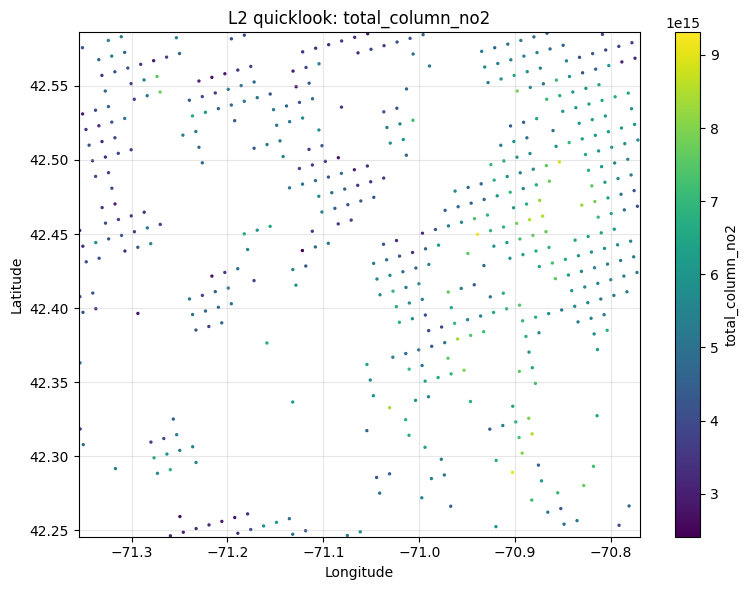

  Median pixel width  (km): 1.1427701711654663
  Median pixel height (km): 1.2052003741264343


In [ ]:

location_name = 'Boston'
bbox_s_w_n_e = (42.245660, -71.355180, 42.586159, -70.770075)
date_str = '2025-08-23'

preview = preview_single_day(
    product='L2',          # or 'L3'
    date_str=date_str,
    bbox_s_w_n_e=bbox_s_w_n_e,
    var_name='total_column_no2',
    cleanup_raw=False,     # keep temp raw files for inspection
)



## Example 2: download a date range and save only clipped files


In [ ]:



location_name = 'Boston'
# extent = [-71.4, -70.7, 42.2, 42.9]#bigger
bbox_s_w_n_e = (42.245660, -71.355180, 42.586159, -70.770075)
tspan = ('2025-08-23', '2025-09-01')

saved = download_and_clip_range(
    product='L2',          # or 'L3'
    location_name=location_name,
    tspan=tspan,
    bbox_s_w_n_e=bbox_s_w_n_e,
    var_name='total_column_no2',
    overwrite=False,
    cleanup_temp=True,
)

print(f'\nSaved {len(saved)} clipped files')


Found 12 matching granules for L2


QUEUEING TASKS | :   0%|          | 0/12 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/12 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/12 [00:00<?, ?it/s]

Saved: /content/drive/MyDrive/IDS.S21/data/L2_oci/L2/Boston/L2_Boston_20250824_PACE_OCI.20250824T171336.L2.TRGAS.V3_0.nc
Saved: /content/drive/MyDrive/IDS.S21/data/L2_oci/L2/Boston/L2_Boston_20250825_PACE_OCI.20250825T161020.L2.TRGAS.V3_0.nc
Saved: /content/drive/MyDrive/IDS.S21/data/L2_oci/L2/Boston/L2_Boston_20250825_PACE_OCI.20250825T174840.L2.TRGAS.V3_0.nc
Saved: /content/drive/MyDrive/IDS.S21/data/L2_oci/L2/Boston/L2_Boston_20250826_PACE_OCI.20250826T164524.L2.TRGAS.V3_0.nc
Saved: /content/drive/MyDrive/IDS.S21/data/L2_oci/L2/Boston/L2_Boston_20250827_PACE_OCI.20250827T172028.L2.TRGAS.V3_0.nc
Saved: /content/drive/MyDrive/IDS.S21/data/L2_oci/L2/Boston/L2_Boston_20250828_PACE_OCI.20250828T161712.L2.TRGAS.V3_0.nc
Saved: /content/drive/MyDrive/IDS.S21/data/L2_oci/L2/Boston/L2_Boston_20250828_PACE_OCI.20250828T175532.L2.TRGAS.V3_0.nc
Saved: /content/drive/MyDrive/IDS.S21/data/L2_oci/L2/Boston/L2_Boston_20250829_PACE_OCI.20250829T165216.L2.TRGAS.V3_0.nc
Saved: /content/drive/MyDrive/ID


## Example 3: reopen a saved clipped file later


In [ ]:

saved_files = list_saved_files(product='L2', location_name='Boston')

if saved_files:
    ds = xr.open_dataset(saved_files[0], engine='h5netcdf')
    print(ds)


/content/drive/MyDrive/IDS.S21/data/L2_oci/L2/Boston/L2_Boston_20250824_PACE_OCI.20250824T171336.L2.TRGAS.V3_0.nc
/content/drive/MyDrive/IDS.S21/data/L2_oci/L2/Boston/L2_Boston_20250825_PACE_OCI.20250825T161020.L2.TRGAS.V3_0.nc
/content/drive/MyDrive/IDS.S21/data/L2_oci/L2/Boston/L2_Boston_20250825_PACE_OCI.20250825T174840.L2.TRGAS.V3_0.nc
/content/drive/MyDrive/IDS.S21/data/L2_oci/L2/Boston/L2_Boston_20250826_PACE_OCI.20250826T164524.L2.TRGAS.V3_0.nc
/content/drive/MyDrive/IDS.S21/data/L2_oci/L2/Boston/L2_Boston_20250827_PACE_OCI.20250827T172028.L2.TRGAS.V3_0.nc
/content/drive/MyDrive/IDS.S21/data/L2_oci/L2/Boston/L2_Boston_20250828_PACE_OCI.20250828T161712.L2.TRGAS.V3_0.nc
/content/drive/MyDrive/IDS.S21/data/L2_oci/L2/Boston/L2_Boston_20250828_PACE_OCI.20250828T175532.L2.TRGAS.V3_0.nc
/content/drive/MyDrive/IDS.S21/data/L2_oci/L2/Boston/L2_Boston_20250829_PACE_OCI.20250829T165216.L2.TRGAS.V3_0.nc
/content/drive/MyDrive/IDS.S21/data/L2_oci/L2/Boston/L2_Boston_20250830_PACE_OCI.2025083

In [ ]:



quicklook_plot(ds, product, var_name='total_column_no2', bbox_s_w_n_e=None,
                   vmin=None, vmax=None, robust=True, figsize=(8, 6), cmap='viridis')

